In [13]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# for day in range(6):
#     print(day)
#     sess = stx.utilities.load_vr_day('mCherry9', day, verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')
#     sess.novel_arm = -1
#     sess._abc_impl = None
#     # sess._abc = None
#     tpu.sess.save_session(sess,'/mnt/BigDisk/YMaze_VR_Pkls')


0
1
2
3
4
5


In [45]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS3_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [40]:
rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for day in range(6):
        print(day)
        for mouse in mice:
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day, trial_mat_keys = ('nonconsum_licks','licks_sum'),verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                plot_vec = np.zeros([140,])*np.nan
                
                licks = sess.trial_matrices['licks_sum'][trial_mask,:]
                rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
                rzone_lick_plot_vec = np.nansum(licks[:,rzone-5:rzone+1], axis=1)/(np.nansum(licks,axis=1)+1E-3)
                plot_vec[:rzone_lick_plot_vec.shape[0]] = rzone_lick_plot_vec

                rows.append({'cond': cond,
                             'mouse': mouse,
                             'day': day,
                             'ttype': ttype,
                             'rzone_licks': rzone_licks,
                             'rzone_licks_plot_vec': plot_vec,
                             })
df = pd.DataFrame(rows)
                
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1


/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))


4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2


/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))


4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1


/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: inva

4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9


/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_451145/1918071077.py:33: RuntimeWarning: inva

/tmp/ipykernel_451145/1401445118.py:11: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(lick_acc,axis=0)


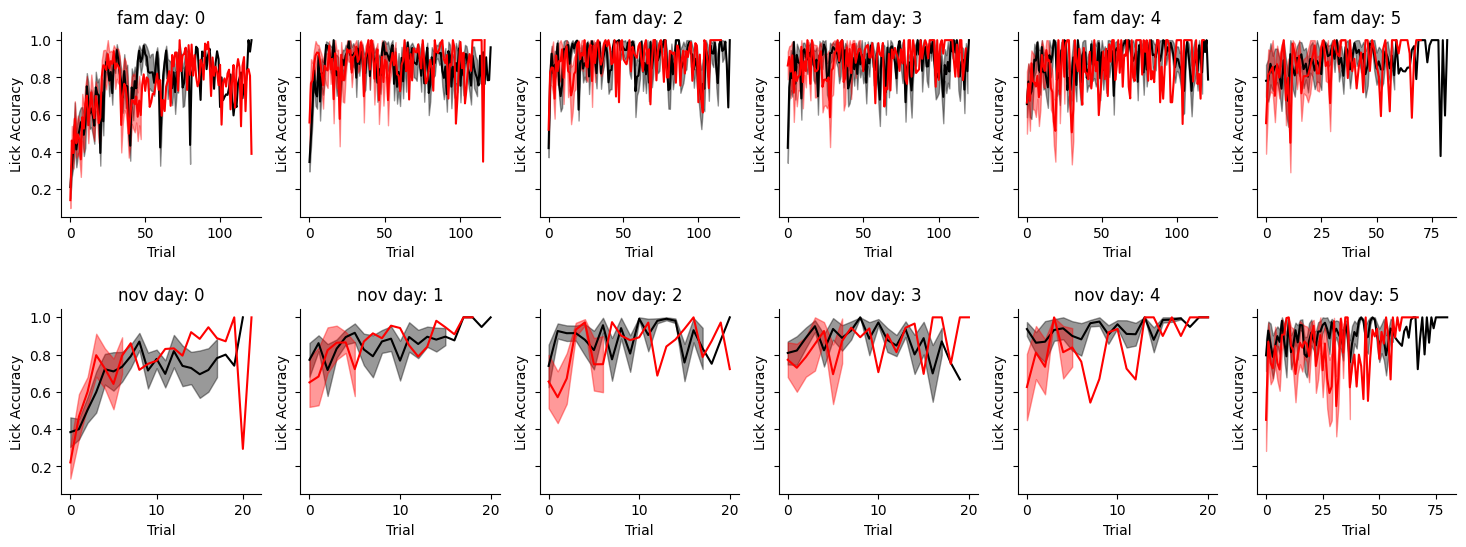

In [46]:
days = np.arange(6)
fig, ax = plt.subplots(2,6, figsize=[18,6], sharey=True)
fig.subplots_adjust(hspace=.5)
for  cond, mice, color in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice), ('black', 'red')): 
    for i, ttype in enumerate(('fam', 'nov')):
        for day in days:
            mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

            # print(np.vstack(df.loc[mask, 'rzone_licks_plot_vec'].values).shape)
            lick_acc = np.vstack(df.loc[mask, 'rzone_licks_plot_vec'].values)
            mu = np.nanmean(lick_acc,axis=0)
            sem = sp.stats.sem(lick_acc,axis=0)
            x = np.arange(mu.shape[0])
            ax[i,day].plot(x, mu, color=color)
            ax[i,day].fill_between(x, mu-sem, mu+sem, alpha=.4, color=color)

            ax[i,day].set_title(f'{ttype} day: {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Trial')
    a.set_ylabel('Lick Accuracy')

fig.savefig(figdir / "lick_accuracy_v_days.pdf")